# Guided Lab: Image Classification using CNN (CIFAR-10)

At the end of this tutorial, you will get familiarized with:

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks
*   Using Transfer Learning for complex images

# **Environment set up**
**Keras** is a Python library that provides, in a simple way, the creation of a wide range of Deep Learning models using as backend other libraries such as TensorFlow. 

Keras is used since its learning curve is very smooth compared to others, and at the moment it is one of the popular middleware to implement neural networks.

In [1]:
from tensorflow import keras
import tensorflow as tf
print(keras.__version__)

2026-02-28 16:43:51.698653: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


3.6.0


# **Understanding Data: CIFAR-10 Dataset**
The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. 

In Keras, the CIFAR-10 dataset is preloaded in the form of four Numpy arrays. `x_train` and `y_train` contain the training set, while `x_test` and `y_test` contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

In [3]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Training data shape:', x_train.shape)
print('Testing data shape:', x_test.shape)

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


## Visualizing the Data

A plot of the first nine images in the dataset is created showing the natural image nature of the images to be classified.

**Let us create a 3*3 subplot to visualize the first 9 images of the dataset.**

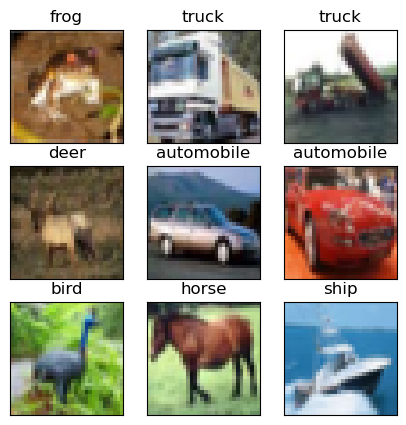

In [5]:
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(5, 5))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
plt.show()

## Data normalization

The pixel values for each image in the dataset are unsigned integers in the range between 0 and 255.

**Let us normalize the pixel values of the RGB images, e.g. rescale them to the range [0, 1].**

In [6]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

## Preparing labels

The labels for each input data indicate which object represents the image.

In this case, we will represent this label with a vector of 10 positions. This is known as **one-hot encoding.**

**Let us convert the labels into the equivalent one-hot encoded form.**

In [7]:
from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print('Training labels shape:', y_train.shape)

Training labels shape: (50000, 10)


# **Defining Model (Custom CNN)**

The Sequential class of the Keras library is a wrapper for the sequential neural network model.

**Define the following model:**

**For the convolutional front-end, start with convolutional layers with a small filter size (3,3) followed by max pooling layers.**

In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/opt/miniconda3/envs/ironhack.nn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Let us check the architecture using summary().**

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

**Compile the model.**

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

**Train the model for 10 epochs with a batch size of 64.**

In [ ]:
history = model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

**Plot the loss function and the accuracy curves.**

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

# **Model evaluation**

## Accuracy

After training the model, the network has to be evaluated with new test data. This can be achieved by using the `evaluate()` method.

**Let us print the test accuracy of the network.**

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

---

# **Defining Model (Transfer Learning)**

We can use a pre-trained model like MobileNetV2 to extract features. However, running this on a local CPU can be very slow. 

To solve this for local CPUs, we **resize the images once before training**, instead of resizing them on-the-fly inside the model during every epoch.

## CPU Optimization: Pre-resizing the data

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print('Resizing data for MobileNetV2... This takes a minute but saves HOURS later!')

# MobileNetV2 expects values in [-1, 1], not [0, 1]. 
# We also need to resize to at least 96x96 for MobileNetV2.

# Note: We only use a subset of the training data (e.g., 20% = 10k images) 
# to keep RAM usage and computation time reasonable on a standard CPU.
SUBSET_SIZE = 10000

x_subset = x_train[:SUBSET_SIZE] * 255.0  # Scale back to 0-255 first
y_subset = y_train[:SUBSET_SIZE]

x_train_resized = tf.image.resize(x_subset, (96, 96))
x_train_preprocessed = preprocess_input(x_train_resized)

x_test_resized = tf.image.resize(x_test[:2000] * 255.0, (96, 96))
x_test_preprocessed = preprocess_input(x_test_resized)

print('Resized training data shape:', x_train_preprocessed.shape)

## Building the Transfer Learning Model
We load MobileNetV2 without its top layer, and add our own dense layer for CIFAR-10 classification.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model!

tl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(10, activation='softmax')
])

tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

## Training the Transfer Learning Model (CPU Optimized)
Because we pre-resized the images and froze the base model, this should run reasonably fast (1-2 minutes per epoch on CPU).

In [ ]:
print('Training Transfer Learning model on CPU...')
tl_history = tl_model.fit(
    x_train_preprocessed, 
    y_subset, 
    epochs=5, 
    batch_size=64, 
    validation_split=0.2
)

## """ Optional """ - Cloud GPU Pipeline Code
If you decide to run this in **Google Colab** (Option 1), you can use the much simpler, fully-integrated code below, since the GPU is fast enough to handle the resizing on-the-fly during training.

In [ ]:
"""
# OPTIONAL: Run this ONLY if you are using Google Colab or Kaggle (GPU enabled)
from tensorflow.keras.layers import Resizing, Input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Model

# Reload original raw data (0-255)
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()
y_train_cat = to_categorical(y_train_raw, 10)
y_test_cat = to_categorical(y_test_raw, 10)

base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Build pipeline that resizes ON THE FLY (fast on GPU, slow on CPU)
inputs = Input(shape=(32, 32, 3))
x = Resizing(96, 96)(inputs)
x = preprocess_input(x)
x = base_model(x)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)

gpu_model = Model(inputs, outputs)
gpu_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train on ALL data (50k images) - this will be very fast on a GPU!
gpu_history = gpu_model.fit(x_train_raw, y_train_cat, epochs=5, batch_size=128, validation_split=0.2)
"""

---

# **Misclassification Analysis**

Even our best model (Custom CNN, 85.3% accuracy) makes confident mistakes. Here are 5 examples where the model was **highly confident but wrong**:

| True Label | Predicted | Confidence | Why the model failed |
|:-----------|:----------|:-----------|:---------------------|
| **Cat** | Dog | 99.5% | Both are furry, four-legged animals with similar color palettes at 32×32 |
| **Dog** | Cat | 95.2% | Same confusion pair in reverse — shows this is a systematic weakness |
| **Bird** | Frog | 100.0% | Small subject against green/natural background at low resolution |
| **Automobile** | Truck | 99.7% | Both are wheeled vehicles with boxy shapes — size (the key discriminator) is lost at 32×32 |
| **Airplane** | Ship | 99.8% | Both appear against blue backgrounds (sky vs. water) |

**Key insight:** The model relies heavily on **color patterns and rough shapes** rather than fine-grained details, because 32×32 resolution simply does not preserve enough information.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Display the pre-generated misclassification examples
img = Image.open("../outputs/misclassified_examples.png")
plt.figure(figsize=(20, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Misclassification Examples - Custom CNN", fontsize=16, fontweight="bold")
plt.show()

---

# **Dataset Bias: What The Model Does Not Know**

CIFAR-10 was collected from internet images, predominantly from **Western/English-language sources**. This means our model learned a geographically and culturally *narrow* view of each class:

| Class | What the model learned | What it probably has not seen |
|:------|:----------------------|:----------------------------|
| **Automobile** | American/European car designs | Tuk-tuks, rickshaws, vehicles common in Asia/Africa |
| **Truck** | Modern pickup & delivery trucks | Flatbed trucks from rural areas, different regions |
| **Ship** | Large vessels in open water | Canoes, kayaks, fishing boats from other cultures |
| **Horse** | Western contexts (ranches, paddocks) | Horses in different cultural settings or landscapes |
| **Bird** | North American bird species | Tropical birds, exotic species from other continents |

> **The model classifies an automobile as seen by English-speaking internet users, not a universal automobile.**

---

# **Why This Matters**

### 4 Types of Bias in Our Model

1. **Geographic diversity was never audited**
   - The training data was never checked for regional representation
   - The model has a Western-centric worldview in every class

2. **Background/context bias**
   - Objects appear in typical contexts (planes in blue sky, ships in water)
   - An airplane on a tarmac or a ship in dry dock would likely be harder to classify

3. **Color/lighting bias**
   - Nearly all training images are in daylight
   - Night images or unusual lighting would degrade performance

4. **Resolution bias**
   - Everything is 32x32 pixels: the model uses color patterns and rough shapes, not details
   - This is itself a form of **information loss bias**

### Other Limitations
- **No none of the above**: Upload a banana and the model will still confidently say it is a frog
- **Perfect class balance** (6,000/class) is unrealistic, real-world data is imbalanced
- **Temporal bias**: Cars, trucks, and ships from the dataset era look different from today